## Importing Library

In [252]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.ensemble import IsolationForest
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import distance
import os
from time import time
from sklearn.decomposition import PCA

## Load the data

In [253]:
data = pd.read_csv('../data/Grey_Boy_2023_2024.csv')
# mapping = pd.read_excel('../data/DECP Master Tag List.xlsx')
# mapping_tag_name=dict(zip(mapping['Variable Tag'] , mapping['Variable Name']))
# mapping_tag_name['datetime']='datetime'
# data.columns=data.columns.map(mapping_tag_name)

In [254]:
data.shape

(4855680, 42)

In [ ]:
filter_key = 'Grey Boy Motor Current'

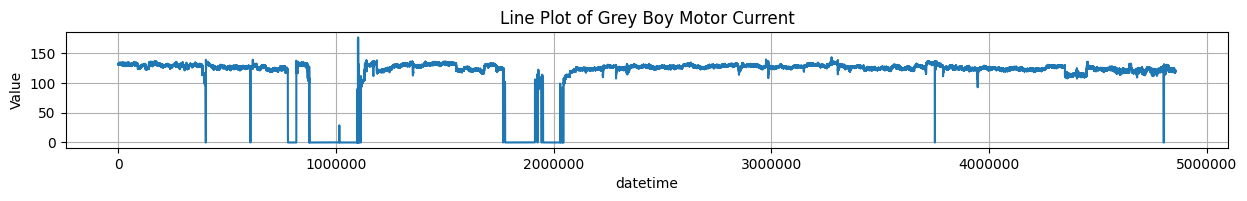

In [256]:
data[filter_key].plot(kind='line', figsize=(15, 1.5))
plt.title(f"Line Plot of {filter_key}")
plt.xlabel('datetime')
plt.ylabel('Value')
plt.ticklabel_format(useOffset=False, style='plain')
plt.grid(True)
plt.show()

## Remove low variance columns

In [257]:
master_df =[]
removed_df = []
shape_and_time ={}
# plot_columns = ['MR Expander Suction Pressure',
#                   'MR Expander Suction Temperature',
#                 'MR Expander Differential Pressure',
#                    'MR Expander Discharge Pressure',
#                 'MR Expander Discharge Temperature',
#                       'MR Expander Generator Power',]

## Step 1: Scale the data using StandardScaler

In [258]:
def remove_low_variance_columns(df, variance_threshold=1e-5):

    if 'datetime' in df.columns:
        datetime_col = df['datetime']
        df = df.drop(columns=['datetime'])  # Exclude datetime before variance calculation
    else:
        datetime_col = None

    # Compute variance of each column
    variances = df.var(numeric_only=True)
    
    # Identify low-variance columns
    low_variance_cols = variances[variances <= variance_threshold].index.tolist()
    
    # Drop these columns
    df_cleaned = df.drop(columns=low_variance_cols)
    
    # Reattach datetime column if present
    if datetime_col is not None:
        df_cleaned['datetime'] = datetime_col
    
    print(f"Removed {len(low_variance_cols)} columns with low variance.")
    
    return df_cleaned, low_variance_cols

In [259]:
def scale_data(data, method ='standard'):    
    # Initialize the scaler and fit-transform the data
    data,low_variance_cols = remove_low_variance_columns(data)
    print(low_variance_cols)
    
    if method=='standard':
        print('inside standard')
        scaler = StandardScaler()
    elif method=='min-max':
        print('inside min-max')
        scaler = MinMaxScaler() # (clip negatives or shift beforehand)
    elif method=='robust':
        print('inside robust')

        scaler = RobustScaler() # (less sensitive to outliers
    else:
        scaler = StandardScaler()

    print(scaler)
    scaled_data = scaler.fit_transform(data.drop(columns=['datetime']))
        
    # Preserve the original DataFrame indices and datetimes
    datetimes = data['datetime']
    original_indices = data.index  
    
    # Create the scaled DataFrame
    good_scale_df = pd.DataFrame(
        scaled_data,
        index=original_indices,
        columns=data.drop(columns=['datetime']).columns
    )
    good_scale_df['datetime'] = datetimes.values
    good_scale_df = good_scale_df.reset_index(drop=True)
       
    return  good_scale_df


## Filter data using key_filter

In [ ]:
def filter_data(df, filter_key):
    df =df[df[filter_key]>50]
    threshold = 0.1 * len(df)  # 20% threshold
    df = df.dropna(thresh=threshold, axis=1)  # Drop columns exceeding missing threshold
    df = df.dropna()
    df = df.drop_duplicates() # drop duplicate rows
    
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    print('df after filtering:', df.shape)
    df.reset_index(drop=True,inplace=True)
    return df

data = filter_data(data,filter_key)

df after filtering: (4340455, 42)


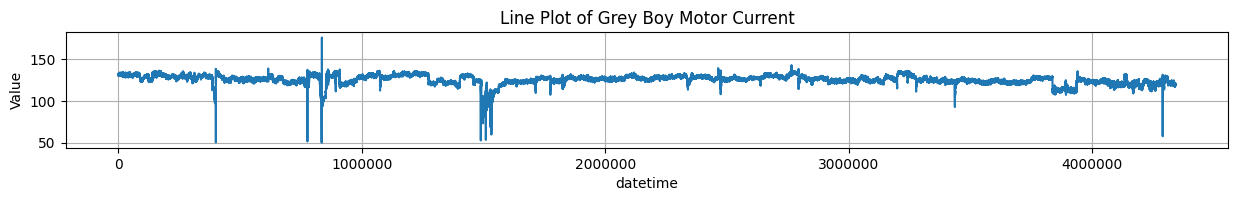

In [261]:
data[filter_key].plot(kind='line', figsize=(15, 1.5))
plt.title(f"Line Plot of {filter_key}")
plt.xlabel('datetime')
plt.ylabel('Value')
plt.ticklabel_format(useOffset=False, style='plain')
plt.grid(True)
plt.show()

In [262]:
data.shape

(4340455, 42)

In [263]:
data=data.loc[:, ~data.columns.isna()]

In [264]:
data.shape

(4340455, 42)

In [265]:
data = scale_data(data, method='standard')

Removed 3 columns with low variance.
['Grey Boy DE Radial Vibration Y', 'Grey Boy NDE Radial Vibration X', 'Grey Boy Gearbox HS Shaft Radial Vibration Y']
inside standard
StandardScaler()


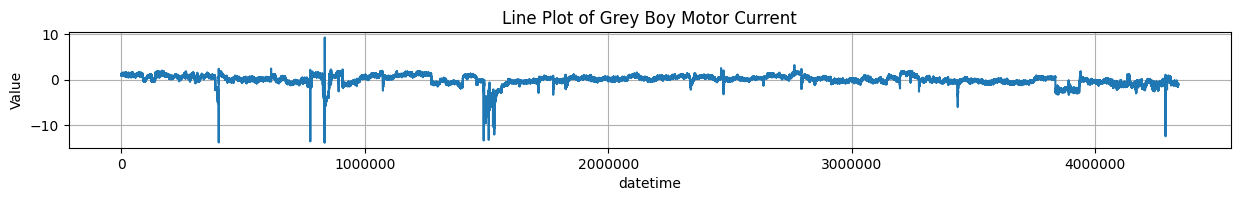

In [266]:
data[filter_key].plot(kind='line', figsize=(15, 1.5))
plt.title(f"Line Plot of {filter_key}")
plt.xlabel('datetime')
plt.ylabel('Value')
plt.ticklabel_format(useOffset=False, style='plain')
plt.grid(True)
plt.show()

In [235]:
test.head()

,Grey Boy Suction Pressure,Grey Boy Suction Flow,Grey Boy Discharge Pressure,Main Air Compressors Discharge Header Pressure,Main Air Compressors Discharge Header Flow,Main Air Compressors Discharge Header Flow.1,Main Air Compressors Discharge Header Flow Controller Output,Main Air Compressors Discharge Header Temperature Downstream Air Heater,Grey Boy Lube Oil Header Pressure A,Grey Boy Lube Oil Header Pressure B,...,Grey Boy Gearbox LS Shaft Radial Vibration Y,Grey Boy Gearbox HS Shaft Radial Vibration X,Grey Boy Motor Current,Grey Boy Suction Valve Controller Output,Grey Boy Vent Valve Controller Output,Grey Boy Vent Valve Controller Output.1,Grey Boy Vent Valve Position Feedback Setpoint,Grey Boy Auxiliary Lube Oil Pump Run Status,Grey Boy Suction Valve Position Feedback Setpoint,datetime
0,0.585054,-0.235155,0.870968,0.899185,0.657040,1.002924,1.981614,0.622170,0.377522,0.384615,...,0.000000,1.166667,-0.355616,0.464666,-0.8375,-0.8932,-0.837375,0.0,0.462824,2024-06-06 06:54:50
1,0.586037,-0.237330,0.869501,0.895753,0.677336,1.017382,1.981973,0.623168,0.308357,0.313609,...,0.000000,0.666667,-0.361429,0.465061,-0.8375,-0.8932,-0.837375,0.0,0.463350,2024-06-06 06:55:00
2,0.587021,-0.239505,0.868524,0.891892,0.697575,1.031840,1.982332,0.624166,0.268012,0.272189,...,-0.666667,-0.500000,-0.367413,0.465588,-0.8375,-0.8932,-0.837375,0.0,0.463745,2024-06-06 06:55:10
3,0.588004,-0.243209,0.867058,0.888460,0.681202,1.046298,1.982691,0.625165,0.556196,0.559172,...,-2.000000,0.500000,-0.373397,0.466114,-0.8375,-0.8932,-0.837375,0.0,0.464272,2024-06-06 06:55:20
4,0.588987,-0.246913,0.866080,0.891463,0.640325,0.979775,1.983049,0.626163,0.299712,0.316568,...,-0.333333,-1.166667,-0.379381,0.466640,-0.8375,-0.8932,-0.837375,0.0,0.464798,2024-06-06 06:55:30


In [203]:
test.head()

,Grey Boy Suction Pressure,Grey Boy Suction Flow,Grey Boy Discharge Pressure,Main Air Compressors Discharge Header Pressure,Main Air Compressors Discharge Header Flow,Main Air Compressors Discharge Header Flow.1,Main Air Compressors Discharge Header Flow Controller Output,Main Air Compressors Discharge Header Temperature Downstream Air Heater,Grey Boy Lube Oil Header Pressure A,Grey Boy Lube Oil Header Pressure B,...,Grey Boy Gearbox LS Shaft Radial Vibration Y,Grey Boy Gearbox HS Shaft Radial Vibration X,Grey Boy Motor Current,Grey Boy Suction Valve Controller Output,Grey Boy Vent Valve Controller Output,Grey Boy Vent Valve Controller Output.1,Grey Boy Vent Valve Position Feedback Setpoint,Grey Boy Auxiliary Lube Oil Pump Run Status,Grey Boy Suction Valve Position Feedback Setpoint,datetime
0,0.816228,-0.399012,0.880413,1.118105,0.607988,0.738300,1.673022,-0.133348,0.586084,0.590181,...,0.266615,1.670001,-0.261440,0.334926,-0.826194,-0.879458,-0.826378,-0.047803,0.332841,2024-06-06 06:54:50
1,0.817571,-0.402085,0.879288,1.114686,0.613869,0.744377,1.673374,-0.133181,0.516863,0.519993,...,0.266615,1.068832,-0.267654,0.335380,-0.826194,-0.879458,-0.826378,-0.047803,0.333445,2024-06-06 06:55:00
2,0.818913,-0.405157,0.878538,1.110840,0.619733,0.750455,1.673726,-0.133015,0.476485,0.479050,...,-0.342411,-0.333896,-0.274050,0.335984,-0.826194,-0.879458,-0.826378,-0.047803,0.333898,2024-06-06 06:55:10
3,0.820255,-0.410388,0.877413,1.107421,0.614989,0.756532,1.674078,-0.132848,0.764905,0.762726,...,-1.560462,0.868442,-0.280447,0.336589,-0.826194,-0.879458,-0.826378,-0.047803,0.334502,2024-06-06 06:55:20
4,0.821598,-0.415620,0.876663,1.110412,0.603145,0.728570,1.674430,-0.132682,0.508211,0.522918,...,-0.037898,-1.135455,-0.286843,0.337193,-0.826194,-0.879458,-0.826378,-0.047803,0.335107,2024-06-06 06:55:30


In [ ]:
file_path='standard'
test=data.iloc[4000000:]
test=test.reset_index(drop=True)
test.to_csv(f'clean_data/{file_path}_scaling/Grey_Boy_pred_data.csv',index=False)

In [268]:
data=data.iloc[:4000000]
data=data.reset_index(drop=True)
data['datetime'] = pd.to_datetime(data['datetime'])
data=data.reset_index(drop=True)
data.shape

(4000000, 39)

In [269]:
scaled_data=data.drop(columns=['datetime']).to_numpy()

In [270]:
data.columns.values

array(['Grey Boy Suction Pressure', 'Grey Boy Suction Flow',
       'Grey Boy Discharge Pressure',
       'Main Air Compressors Discharge Header Pressure',
       'Main Air Compressors Discharge Header Flow',
       'Main Air Compressors Discharge Header Flow.1',
       'Main Air Compressors Discharge Header Flow Controller Output',
       'Main Air Compressors Discharge Header Temperature Downstream Air Heater',
       'Grey Boy Lube Oil Header Pressure A',
       'Grey Boy Lube Oil Header Pressure B',
       'Grey Boy Discharge Temperature A',
       'Grey Boy Discharge Temperature B',
       'Grey Boy Motor Winding A Temperature',
       'Grey Boy Motor Winding B Temperature',
       'Grey Boy Motor Winding C Temperature',
       'Grey Boy Motor DE Bearing Temperature',
       'Grey Boy Motor NDE Bearing Temperature',
       'Grey Boy NDE Bearing Temperature A',
       'Grey Boy DE Bearing Temperature A',
       'Grey Boy DE Bearing Temperature B',
       'Grey Boy NDE Bearing Tempe

In [271]:
plot_columns = ['Grey Boy Suction Pressure', 'Grey Boy Suction Flow',
               'Grey Boy Discharge Pressure',
               'Main Air Compressors Discharge Header Pressure',
               'Grey Boy DE Bearing Temperature A',
               'Grey Boy DE Bearing Temperature B',
               'Grey Boy Motor Current',
               ]

In [272]:
# Track the shape and time taken
shape_and_time['Initial_Scaled_df']= {'Shape': data.shape, 'Time': 1.454545 }
master_df.append(data[plot_columns])
removed_df.append(data[plot_columns])


In [273]:
def plot_density_and_time_series(df1):
    df=df1.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)  # Ensure datetime is the index


    for column  in df.columns:        
        # Create a figure with subplots
        if column!='datetime':
            fig, axes = plt.subplots(1, 2, figsize=(10, 2))
            # Density (KDE) plot
            sns.histplot(df[column], bins=30, kde=False, ax=axes[0], color='blue', edgecolor='black')
            axes[0].set_title(f'Distribution of {column}')
            axes[0].set_xlabel('Value')
            axes[0].set_ylabel('Density')
            axes[0].grid(True)

            # Time-series line plot
            df[column].plot(ax=axes[1], kind='line', color='red')
            axes[1].set_title(f'Time Series of {column}')
            axes[1].set_xlabel('datetime')
            axes[1].set_ylabel('Value')
            axes[1].grid(True)

            # Adjust layout
            plt.tight_layout()
            plt.show()

## Step 2: Initial anomaly detection with Isolation Forest

In [274]:
def detect_anomalies_iso_forest(scaled_data, df, contamination=0.05, random_state=145,number=None,max_feature=1):
    start = time()
    
    # Initialize and fit Isolation Forest
    iso_forest = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1,max_features=max_feature)
    anomaly_scores = iso_forest.fit_predict(scaled_data)
    
    time_taken = time() - start
    
    # Separate good and bad data
    good_data = scaled_data[anomaly_scores == 1]
    good_indices = df.index[anomaly_scores == 1]
    good_datetimes = df['datetime'][anomaly_scores == 1]

    bad_data = scaled_data[anomaly_scores != 1]
    bad_indices = df.index[anomaly_scores != 1]
    bad_datetimes = df['datetime'][anomaly_scores != 1]

    # Create DataFrame for good data
    good_IF_df = pd.DataFrame(
        good_data,
        index=good_indices,
        columns=data.drop(columns=['datetime']).columns
    )
    good_IF_df['datetime'] = good_datetimes.values
    good_IF_df = good_IF_df.reset_index(drop=True)

    # Create DataFrame for bad data
    bad_IF_df = pd.DataFrame(
        bad_data,
        index=bad_indices,
        columns=data.drop(columns=['datetime']).columns
    )
    bad_IF_df['datetime'] = bad_datetimes.values
    bad_IF_df = bad_IF_df.reset_index(drop=True)

    # Update shape and time
    if number is None:
        key_name = 'Isolation_forest_df'
    else:
        key_name = f'Isolation_forest_df{number}'    
    shape_and_time [key_name] = {'Shape': good_IF_df.shape, 'Time': time_taken}
    master_df.append(good_IF_df[plot_columns])
    removed_df.append(bad_IF_df[plot_columns])

    return good_data, good_IF_df


## Step 3: Mahalanobis Distance cleaning

In [275]:
def detect_anomalies_mahalanobis(good_data, df, threshold_multiplier=1):
    start = time()
    
    # Calculate covariance matrix and its inverse
    cov_matrix = np.cov(good_data, rowvar=False)
    inv_cov_matrix = np.linalg.pinv(cov_matrix)  # safer alternative

    mean = np.mean(good_data, axis=0)  
    
    # Mahalanobis Distance Function
    def mahalanobis_distance(x, mean, inv_cov_matrix):
        diff = x - mean
        return np.sqrt(np.dot(np.dot(diff, inv_cov_matrix), diff.T))
    
    # Calculate Mahalanobis distances for each point
    mahalanobis_distances = np.array([mahalanobis_distance(x, mean, inv_cov_matrix) for x in good_data])

    # Determine threshold
    mean_distance = np.mean(mahalanobis_distances)
    std_distance = np.std(mahalanobis_distances)
    mahalanobis_distance_threshold = mean_distance + threshold_multiplier * std_distance
    
    # Identify anomalies
    anomalies = mahalanobis_distances > mahalanobis_distance_threshold
    
    time_taken = time() - start
    
    # Separate good and bad data
    good_data_mahalanobis = good_data[~anomalies]  
    good_indices_mahalanobis = df.index[~anomalies]
    good_datetimes = df['datetime'][good_indices_mahalanobis]  

    bad_data_mahalanobis = good_data[anomalies]  
    bad_indices_mahalanobis = df.index[anomalies]
    bad_datetimes_mahalanobis = df['datetime'][bad_indices_mahalanobis]

    # Create DataFrame for good data
    good_MDC_df = pd.DataFrame(
        good_data_mahalanobis,
        index=good_indices_mahalanobis,
        columns=data.drop(columns=['datetime']).columns
    )
    good_MDC_df['datetime'] = good_datetimes.values
    good_MDC_df = good_MDC_df.reset_index(drop=True)

    # Create DataFrame for bad data
    bad_MDC_df = pd.DataFrame(
        bad_data_mahalanobis,
        index=bad_indices_mahalanobis,
        columns=data.drop(columns=['datetime']).columns
    )
    bad_MDC_df['datetime'] = bad_datetimes_mahalanobis.values
    bad_MDC_df = bad_MDC_df.reset_index(drop=True)

    # Update shape and time
    shape_and_time['Mahalanobis_dist_df']= {'Shape': good_MDC_df.shape, 'Time': time_taken}
    master_df.append(good_MDC_df[plot_columns])
    removed_df.append(bad_MDC_df[plot_columns])
    
    return good_data_mahalanobis, good_MDC_df


## Step 4: PCA-Based Cleaning

In [276]:
def detect_anomalies_pca(good_data,df, n_components=0.97, threshold_multiplier=1.0):
    start = time()
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(good_data)

    # Reconstruct data
    reconstructed_data = pca.inverse_transform(pca_data)

    # Ensure the same shape before calculating reconstruction error
    if good_data.shape == reconstructed_data.shape:
        reconstruction_error = np.linalg.norm(good_data - reconstructed_data, axis=1)
    else:
        raise ValueError(f"Shape mismatch: good_data={good_data.shape}, reconstructed_data={reconstructed_data.shape}")

    # Compute dynamic threshold
    mean_error = np.mean(reconstruction_error)
    std_error = np.std(reconstruction_error)
    error_threshold = mean_error + threshold_multiplier * std_error  

    # Identify anomalies
    anomalies = reconstruction_error > error_threshold
    
    time_taken = time() - start

    # Separate good and bad data
    good_data_PCA = good_data[~anomalies]  
    good_indices_PCA = df.index[~anomalies]
    good_datetimes = df['datetime'][good_indices_PCA]  

    bad_data_PCA = good_data[anomalies]  
    bad_indices_PCA = df.index[anomalies]
    bad_datetimes_PCA = df['datetime'][bad_indices_PCA]

    # Create DataFrame for good data
    good_PCA_df = pd.DataFrame(
        good_data_PCA,
        index=good_indices_PCA,
        columns=data.drop(columns=['datetime']).columns
    )
    good_PCA_df['datetime'] = good_datetimes.values
    good_PCA_df = good_PCA_df.reset_index(drop=True)

    # Create DataFrame for bad data
    bad_PCA_df = pd.DataFrame(
        bad_data_PCA,
        index=bad_indices_PCA,
        columns=data.drop(columns=['datetime']).columns
    )
    bad_PCA_df['datetime'] = bad_datetimes_PCA.values
    bad_PCA_df = bad_PCA_df.reset_index(drop=True)

    # Update shape and time
    shape_and_time['PCA_Clean_df']= {'Shape': good_PCA_df.shape, 'Time': time_taken}
    master_df.append(good_PCA_df[plot_columns])
    removed_df.append(bad_PCA_df[plot_columns])
    
    return good_data_PCA, good_PCA_df


## Corrrelation Based_Cleaning

In [277]:
def plot_coorelation_result(values):
    # Create the figure and subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Top: Histogram with KDE
    sns.histplot(values, bins=30, kde=True, color='blue', edgecolor='black', ax=axes[0])
    axes[0].set_title("Histogram of Correlation Norms")
    axes[0].set_xlabel("Correlation Norm Value")
    axes[0].set_ylabel("Frequency")

    values=values[::2]
    # Bottom: Scatter plot with index on x-axis
    indices = np.arange(len(values))
    axes[1].plot(indices, values, color='blue', alpha=0.7, linestyle='--', marker='o')
    axes[1].set_title("Trend of Correlation Norms Over Time")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("Correlation Norm Value")
    
    plt.tight_layout()
    plt.show()

In [278]:
def detect_anomalies_correlation(good_data, df, row_threshold=10, resample_freq='12h', std_multiplier=1.0):
    start = time()
    
    # Initialize lists for storing time chunks and valid indices
    time_chunks = []
    valid_indices = []

    # Resample and filter groups
    for _, group in df.resample(resample_freq, on='datetime'):
        if len(group) > row_threshold:
            time_chunks.append(group)
            valid_indices.extend(group.index)

    # Retain only valid rows in df
    filtered_df = df.loc[valid_indices].reset_index(drop=True)

    # Compute correlation matrices for each time chunk
    correlation_matrices = [chunk.drop(columns=['datetime']).corr() for chunk in time_chunks]
    # Compare correlation matrices using Frobenius norm
    # norms = [np.linalg.norm(corr.fillna(0), ord='fro') for corr in correlation_matrices]

    norms=[]
    for i in range(len(correlation_matrices) - 1):
        # Replace NaN values with 0
        corr1 = correlation_matrices[i].fillna(0)
        corr2 = correlation_matrices[i + 1].fillna(0)
        # Compute Frobenius norm difference
        diff = np.linalg.norm(corr1 - corr2, ord='fro')
        norms.append(diff)

    # plot_coorelation_result(norms)
    print('No of data chunks: ',len(time_chunks))

    # Set a threshold for identifying anomalous correlation matrices
    threshold = np.mean(norms) + std_multiplier * np.std(norms)
    print("Threshold calcluated for correaltion :", threshold)

    # Identify indices of anomalous correlation matrices
    anomalous_indices = [i for i, diff in enumerate(norms) if diff > threshold]

    # Filter out anomalous time chunks
    filtered_chunks = [chunk for i, chunk in enumerate(time_chunks) if i not in anomalous_indices]
    anomalous_chunks = [chunk for i, chunk in enumerate(time_chunks) if i in anomalous_indices]

    # Combine filtered chunks into a single DataFrame
    filtered_data_df = pd.concat(filtered_chunks).reset_index(drop=True)
    anomalous_data_df = pd.concat(anomalous_chunks).reset_index(drop=True)

    time_taken = time() - start

    # Update shape and time
    shape_and_time['Coorealtion_Clean_df']= {'Shape': filtered_data_df.shape, 'Time': time_taken}
    
    master_df.append(filtered_data_df[plot_columns])
    removed_df.append(anomalous_data_df[plot_columns])

    return filtered_data_df.drop(columns='datetime',axis=1).to_numpy(),filtered_data_df


## Saving Results in PDF

In [279]:
from matplotlib.backends.backend_pdf import PdfPages

def plot_density_and_time_series(master_dfs,folder_name, method_used, pdf_filename="plots.pdf"):
    dfs = master_dfs.copy()

    folder_path = os.path.join('result', folder_name)
    # Create the folder if it does not exist
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    pdf_path = os.path.join(folder_path, pdf_filename)


    for df in dfs:
        if 'datetime' in df.columns:
            df['datetime'] = pd.to_datetime(df['datetime'])
            df.set_index('datetime', inplace=True)  # Ensure datetime is the index
    
    with PdfPages(pdf_path) as pdf:  # Create a PDF to store plots
        for column in dfs[0].columns:    
            i = 0
    
            for df in dfs:   
                if column != 'datetime':
                    # Create the plot and try reducing the size
                    fig, axes = plt.subplots(1, 2, figsize=(16, 3))  # Reduced size for faster rendering
                    fig.suptitle(f'{column} after {method_used[i]}', fontsize=16)
    
                    # Density (KDE) plot
                    sns.histplot(df[column], bins=20, kde=False, ax=axes[0], color='blue', edgecolor='black')  # Fewer bins for speed
                    axes[0].set_xlabel('Value')
                    axes[0].set_ylabel('Density')
                    axes[0].grid(True)
    
                    # Time-series scatter plot (downsampling every 100th point)
                    downsampled_index = df.index[::1000]
                    downsampled_values = df[column][::1000]
                    
                    axes[1].scatter(downsampled_index, downsampled_values, color='red', s=5, alpha=0.7)
                    axes[1].set_xlabel('Datetime')
                    axes[1].set_ylabel('Value')
                    axes[1].grid(True)
    
                    # Adjust layout and save to PDF
                    plt.tight_layout()
                    # plt.show()
    
                    # Save the figure to the PDF file and free up memory
                    pdf.savefig(fig)
                    plt.close(fig)  # Close the figure to release memory
    
                i += 1

    print(f"Plots saved successfully in {pdf_filename}")

# Function Call

In [280]:

df=data.copy()

# array_data, df = scale_data(data1)
array_data, df = detect_anomalies_pca(scaled_data,df,n_components=0.95)
array_data, df = detect_anomalies_iso_forest(array_data,df,contamination=0.1)
array_data, df = detect_anomalies_mahalanobis(array_data,df)
# array_data, df = detect_anomalies_correlation(array_data,df)


In [281]:
folder_name = 'standard'
# method_use = ['Initial DF', 'Isolation Forest DF', 'Mahalanobis Dist DF','PCA DF', 'Correlation DF']
method_use = ['Initial DF','PCA DF','Isolation Forest DF','Mahalanobis Dist DF',]


plot_density_and_time_series(master_df,folder_name,method_use,pdf_filename="Good_Grey_boy.pdf")
plot_density_and_time_series(removed_df,folder_name,method_use, pdf_filename="Bad_Grey_boy.pdf")

Plots saved successfully in Good_Grey_boy.pdf
Plots saved successfully in Bad_Grey_boy.pdf


In [282]:
shapetime=pd.DataFrame(shape_and_time).T
shapetime.reset_index(inplace=True)
shapetime.columns=['Method Used','DF_Shape','Time(in Seconds)']
shapetime.to_csv(f'result/{folder_name}/time_&_shape.csv',index=False)

In [283]:
df.to_csv(f'clean_data/{folder_name}_scaling/Grey_boy_Clean_Data.csv',index=False)

## End

In [67]:
pip install pywt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pywt (from versions: none)
ERROR: No matching distribution found for pywt
You should consider upgrading via the 'c:\Users\kulsr\Desktop\Autoencoder\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [68]:
import numpy as np
import pywt
from sklearn.ensemble import IsolationForest
 

 
# Wavelet Decomposition
wavelet = 'db1'
coeffs = pywt.wavedec(data, wavelet)
detail_coeffs = coeffs[-1]
 
# Estimate Noise Level using MAD
mad = np.median(np.abs(detail_coeffs - np.median(detail_coeffs)))
sigma = mad / 0.6745
 
# Dynamic Contamination Calculation
data_range = np.max(data) - np.min(data)
contamination = min(max(sigma / data_range, 0.01), 0.5)  # Clamp between 0.01 and 0.5
 
print(f"Estimated Contamination: {contamination}")
 
# Isolation Forest with Dynamic Contamination
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(data.reshape(-1, 1))
anomalies = iso_forest.predict(data.reshape(-1, 1))
 
# Anomalies: -1, Normal: 1
print(f"Anomalies Detected: {np.sum(anomalies == -1)}")

ModuleNotFoundError: No module named 'pywt'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ttest_ind

def calculate_correlation_matrices(df, df1, threshold=-2):
    """
    Divide dataset into two groups based on the threshold for the target feature and calculate correlation matrices:
    - Below the threshold (e.g., < -2)
    - Above the threshold (e.g., >= -2)
    """
    # Convert datetime and set as index
    # df['datetime'] = pd.to_datetime(df['datetime'])
    # df.set_index('datetime', inplace=True)
    
    # Split Dataset
    df_below = df
    df_above = df1
    
    # Calculate Correlation Matrices
    corr_below = df_below.corr().fillna(0)
    corr_above = df_above.corr().fillna(0)
    
    return corr_below, corr_above

from scipy.spatial.distance import euclidean
from scipy.stats import ttest_ind
import numpy as np

def vectorize_and_compare_corrs(corr_matrix1, corr_matrix2):
    """
    Vectorize and compare two correlation matrices using Euclidean distance.
    """
    def vectorize_corr(corr_matrix):
        upper_tri_idx = np.triu_indices_from(corr_matrix, k=1)
        return corr_matrix.values[upper_tri_idx]

    # Vectorize Correlation Matrices
    vector1 = vectorize_corr(corr_matrix1)
    vector2 = vectorize_corr(corr_matrix2)

    # Calculate Euclidean Distance
    distance = euclidean(vector1, vector2)

    # Compare Distributions Using T-test
    t_stat, p_value = ttest_ind(vector1, vector2, equal_var=False)

    return distance, t_stat, p_value

def visualize_correlation_matrices(corr_matrices1, corr_matrices2):
    """
    Visualize example correlation matrices using heatmaps.
    """
    plt.figure(figsize=(15, 6))

    # Plot Example Correlation Matrix for Below Threshold
    plt.subplot(1, 2, 1)
    sns.heatmap(corr_matrices1.fillna(0), annot=False, cmap='coolwarm', center=0)
    plt.title('Example Corr Matrix (Below Threshold)')

    # Plot Example Correlation Matrix for Around Zero
    plt.subplot(1, 2, 2)
    sns.heatmap(corr_matrices2.fillna(0), annot=False, cmap='coolwarm', center=0)
    plt.title('Example Corr Matrix (Around Zero)')
    
    plt.show()

def forb_norm(corr_matrices1, corr_matrices2):
    norms1 = np.linalg.norm(corr_matrices1.fillna(0), ord='fro')
    norms2 = np.linalg.norm(corr_matrices2.fillna(0), ord='fro')

    print('below -2 :',norms1)
    print('above -2 :',norms2)

    

def visualize_distance_distribution(dist1, dist2):
    """
    Visualize the distribution of distances.
    """
    plt.figure(figsize=(10, 5))
    sns.histplot(dist1, color='red', label='Below -2', kde=True, bins=20)
    sns.histplot(dist2, color='blue', label='Around 0', kde=True, bins=20)
    plt.title('Distribution of Correlation Distance')
    plt.legend()
    plt.show()




In [ ]:
master_df =[]
removed_df = []
shape_and_time ={}
data1=data.copy()

array_data, df = scale_data(data)
# array_data, df = detect_anomalies_iso_forest(array_data,df)
# array_data, df = detect_anomalies_mahalanobis(array_data,df)
# array_data, df = detect_anomalies_pca(array_data,df)
# array_data, df = detect_anomalies_correlation(array_data,df)

# array_df, data = scale_data(data)
# array_df, data = scale_data(data)


In [ ]:
df=df[(df['datetime']>'2024-05-10 00:00:00') & (df['datetime']<'2024-06-14 00:00:00')]
df.set_index('datetime', inplace=True)

In [ ]:
df[filter_key].plot(kind='line', figsize=(15, 1.5))
plt.title(f"Line Plot of {filter_key}")
plt.xlabel('datetime')
plt.ylabel('Value')
# plt.ticklabel_format(useOffset=False, style='plain')
plt.grid(True)
plt.show()

In [ ]:
import gc
gc.collect()

In [ ]:
df=data[(data['datetime']>'2024-06-09 00:00:00') & (data['datetime']<'2024-06-09 03:00:00')]
df1=data[(data['datetime']>'2024-05-12 12:00:00') & (data['datetime']<'2024-05-12 15:00:00')]

In [ ]:
# Example Usage
target_feature = 'Grey Boy Motor Current'
corr_below, corr_around_zero = calculate_correlation_matrices(df, df1)
dist_below, t_stat, p_value = vectorize_and_compare_corrs(corr_below, corr_around_zero)

print("T-statistic:", t_stat)
print("P-value:", p_value)
print('distance',dist_below)

# Visualize Example Correlation Matrices
# visualize_correlation_matrices(corr_below, corr_around_zero)
forb_norm(corr_below, corr_around_zero)

# Visualize Distance Distribution


In [ ]:
# Example Usage
target_feature = 'Grey Boy Motor Current'
corr_below, corr_around_zero = calculate_correlation_matrices(df, df1)
dist_below, t_stat, p_value = vectorize_and_compare_corrs(corr_below, corr_around_zero)

print("T-statistic:", t_stat)
print("P-value:", p_value)
print('distance',dist_below)

# Visualize Example Correlation Matrices
visualize_correlation_matrices(corr_below, corr_around_zero)
forb_norm(corr_below, corr_around_zero)

# Visualize Distance Distribution


In [ ]:
corr_around_zero

In [ ]:
master_df =[]
removed_df = []
shape_and_time ={}
data1=data.copy()

array_data, df = scale_data(data1)
# array_data, df = detect_anomalies_iso_forest(array_data,df)
# array_data, df = detect_anomalies_mahalanobis(array_data,df)
# array_data, df = detect_anomalies_pca(array_data,df)
array_data, df = detect_anomalies_correlation(array_data,df)

# array_df, data = scale_data(data)
# array_df, data = scale_data(data)


In [ ]:
array_data.shape

In [ ]:
data.shape

In [ ]:
pd.DataFrame(shape_and_time).T

In [ ]:
len(master_df)

In [ ]:
len(removed_df)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

def plot_density_and_time_series(master_dfs, pdf_filename="plots.pdf"):
    dfs = master_dfs.copy()

    for df in dfs:
        if 'datetime' in df.columns:
            df['datetime'] = pd.to_datetime(df['datetime'])
            df.set_index('datetime', inplace=True)  # Ensure datetime is the index

    df_name = ['Initial DF', 'Isolation Forest DF', 'Mahalanobis Dist DF','PCA DF', 'Correlation DF']
    
    with PdfPages(pdf_filename) as pdf:  # Create a PDF to store plots
        for column in dfs[0].columns:    
            i = 0
    
            for df in dfs:   
                if column != 'datetime':
                    # Create the plot and try reducing the size
                    fig, axes = plt.subplots(1, 2, figsize=(16, 3))  # Reduced size for faster rendering
                    fig.suptitle(f'{column} for {df_name[i]}', fontsize=16)
    
                    # Density (KDE) plot
                    sns.histplot(df[column], bins=20, kde=False, ax=axes[0], color='blue', edgecolor='black')  # Fewer bins for speed
                    axes[0].set_xlabel('Value')
                    axes[0].set_ylabel('Density')
                    axes[0].grid(True)
    
                    # Time-series scatter plot (downsampling every 100th point)
                    downsampled_index = df.index[::1000]
                    downsampled_values = df[column][::1000]
                    
                    axes[1].scatter(downsampled_index, downsampled_values, color='red', s=5, alpha=0.7)
                    axes[1].set_xlabel('Datetime')
                    axes[1].set_ylabel('Value')
                    axes[1].grid(True)
    
                    # Adjust layout and save to PDF
                    plt.tight_layout()
                    # plt.show()
    
                    # Save the figure to the PDF file and free up memory
                    pdf.savefig(fig)
                    plt.close(fig)  # Close the figure to release memory
    
                i += 1

    print(f"Plots saved successfully in {pdf_filename}")


In [ ]:
plot_density_and_time_series(master_df, "result/PCA/Grey_boy_plots_six_months2.pdf")
plot_density_and_time_series(removed_df, "result/PCA/Bad_Grey_boy_plots_six_months2.pdf")

In [ ]:
# clustering other than HDBSCAN.
# how many cluster we should use.
# change resample hours.
# plot anamolus correlation matrix/CLUSTER.
# may be we use change popint before reasmapling.
# plot cluster
# REMOVE CONSTANT COLUMNS, HIGHLY CORRELATED COLUMNS
# LETS SEE HOW TO REMOVE BOEELAN COLUMNS

In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Step 1: Create a small Pandas DataFrame
date_range = pd.date_range(start="2023-01-01", periods=20, freq="D")
data = {
    "datetime": date_range,
    "sensor_value": np.random.rand(20)
}
pdf = pd.DataFrame(data)

# Convert to Dask DataFrame
ddf = dd.from_pandas(pdf, npartitions=4)

# Function Definition
def holdout_parser(df,data_split = 0.90):
    holdout_time = df["datetime"].quantile(data_split)
    holdout_ddf = df[df["datetime"] >= holdout_time]
    ddf = df[(df["datetime"] < holdout_time)]  # Test: Next 20%
    # ddf = DataCleaner.remove_empty_partitions(ddf)
    ddf = ddf.reset_index(drop=True)
    holdout_ddf = holdout_ddf.reset_index(drop=True)
    return holdout_ddf,ddf

# Step 2: Use the holdout_parser function
holdout_ddf, train_ddf = holdout_parser(ddf, data_split=0.50)

# Step 3: Display Results
print("Holdout DataFrame:")
print(holdout_ddf.compute())

print("\nTraining DataFrame:")
print(train_ddf.compute())
